# Series Temporales - Práctica

In [57]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn --quiet

### Aclaración pmdarima solo funciona con python entre 3.8 y 3.11

In [58]:
!python --version

Python 3.13.5


In [59]:
!pip install pmdarima --quiet # si arriba les salió entre 3.8 y 3.11

  error: subprocess-exited-with-error
  
  × Building wheel for pmdarima (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [42 lines of output]
      Partial import of pmdarima during the build process.
      Requirements: ['joblib>=0.11', 'Cython>=0.29,!=0.29.18,!=0.29.31', 'numpy>=1.21.2', 'pandas>=0.19', 'scikit-learn>=0.22', 'scipy>=1.3.2', 'statsmodels>=0.13.2', 'urllib3', 'setuptools>=38.6.0,!=50.0.0', 'packaging>=17.1  # Bundled with setuptools, but want to be explicit']
      Adding extra setuptools args
      Setting up with setuptools
      Traceback (most recent call last):
        File "/Users/fermin/Desktop/UdeSA/Analítica de Datos/env/lib/python3.13/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "/Users/fermin/Desktop/UdeSA/Analítica de Datos/env/lib/python3.13/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_o

## 1. Ejemplos Introductorios

### 1.1 Media Móvil - Ejemplo Manual

Calculemos la media móvil paso a paso con ventas diarias.

Prediccion para dia 11: 29.67


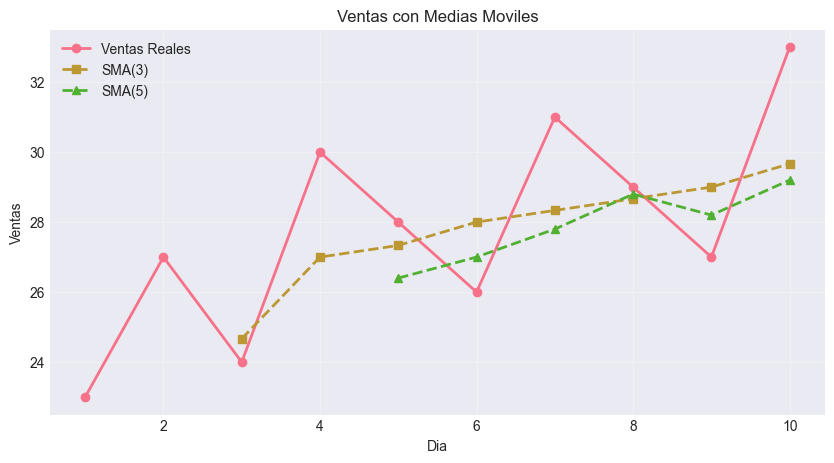

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datos del ejemplo
ventas = [23, 27, 24, 30, 28, 26, 31, 29, 27, 33]
dias = list(range(1, 11))

# Crear serie temporal
ts = pd.Series(ventas, index=dias)

# Media movil simple de orden 3
sma_3 = ts.rolling(window=3).mean()

# Media movil simple de orden 5
sma_5 = ts.rolling(window=5).mean()

# Prediccion para el proximo periodo
prediccion = sma_3.iloc[-1]
print(f"Prediccion para dia 11: {prediccion:.2f}")

# Visualizacion
plt.figure(figsize=(10, 5))
plt.plot(dias, ventas, 'o-', label='Ventas Reales', linewidth=2)
plt.plot(dias, sma_3, 's--', label='SMA(3)', linewidth=2)
plt.plot(dias, sma_5, '^--', label='SMA(5)', linewidth=2)
plt.xlabel('Dia')
plt.ylabel('Ventas')
plt.title('Ventas con Medias Moviles')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1.2 Descomposición Manual - Ejemplo con Ventas Trimestrales

Descomponer manualmente una serie en sus componentes.

Datos originales:
     Año Trimestre  Ventas
0   2021        Q1      10
1   2021        Q2      12
2   2021        Q3      11
3   2021        Q4      15
4   2022        Q1      11
5   2022        Q2      13
6   2022        Q3      12
7   2022        Q4      16
8   2023        Q1      12
9   2023        Q2      14
10  2023        Q3      13
11  2023        Q4      17

Descomposición:
     Año Trimestre  Ventas  Tendencia  Y_t - T_t
0   2021        Q1      10        NaN        NaN
1   2021        Q2      12      12.00       0.00
2   2021        Q3      11      12.25      -1.25
3   2021        Q4      15      12.50       2.50
4   2022        Q1      11      12.75      -1.75
5   2022        Q2      13      13.00       0.00
6   2022        Q3      12      13.25      -1.25
7   2022        Q4      16      13.50       2.50
8   2023        Q1      12      13.75      -1.75
9   2023        Q2      14      14.00       0.00
10  2023        Q3      13        NaN        NaN
11  2023        Q4      17

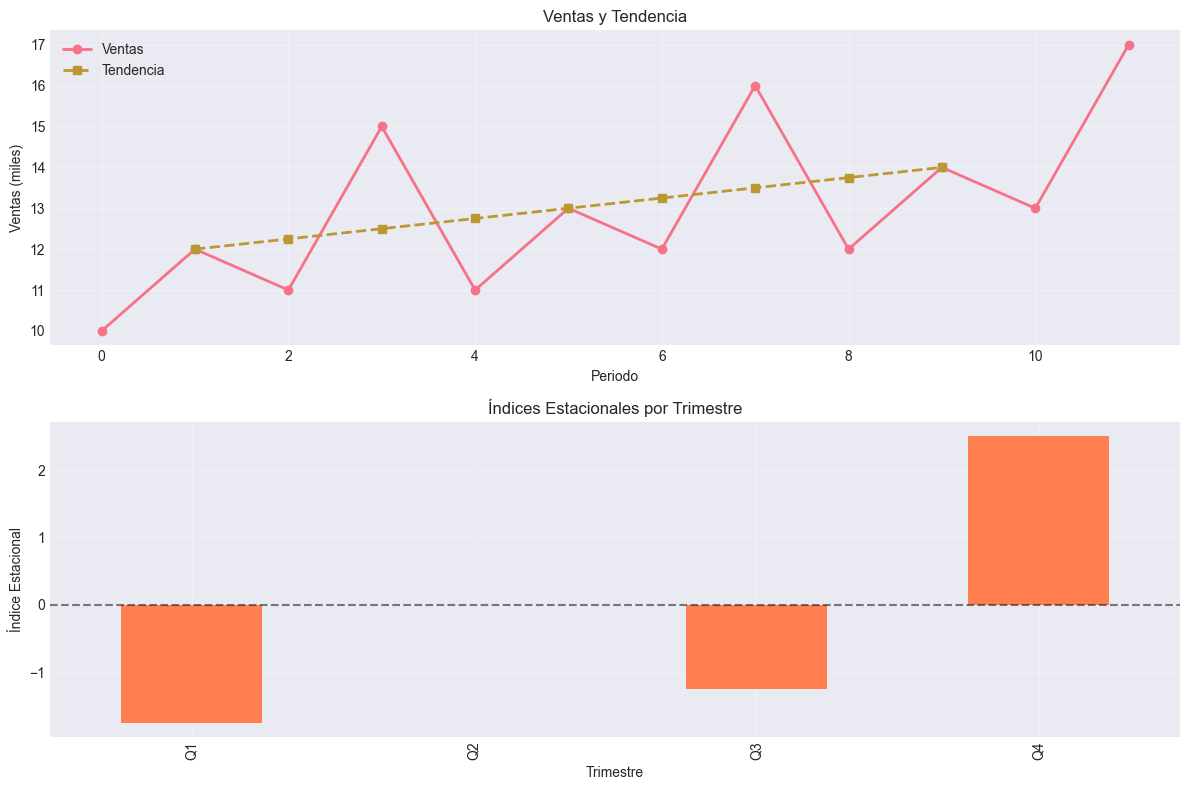

In [61]:
# Ventas trimestrales durante 3 años
data = {
    'Año': [2021, 2021, 2021, 2021, 2022, 2022, 2022, 2022, 2023, 2023, 2023, 2023],
    'Trimestre': ['Q1', 'Q2', 'Q3', 'Q4', 'Q1', 'Q2', 'Q3', 'Q4', 'Q1', 'Q2', 'Q3', 'Q4'],
    'Ventas': [10, 12, 11, 15, 11, 13, 12, 16, 12, 14, 13, 17]
}

df = pd.DataFrame(data)
print("Datos originales:")
print(df)

# Calcular tendencia con media movil centrada de 4 periodos
df['Tendencia'] = df['Ventas'].rolling(window=4).mean().shift(-2)

# Calcular componente desestacionalizada
df['Y_t - T_t'] = df['Ventas'] - df['Tendencia']

print("\nDescomposición:")
print(df[['Año', 'Trimestre', 'Ventas', 'Tendencia', 'Y_t - T_t']])

# Calcular indices estacionales por trimestre
indices_estacionales = df.groupby('Trimestre')['Y_t - T_t'].mean()
print("\nÍndices Estacionales:")
print(indices_estacionales)

# Visualizar
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Serie original y tendencia
axes[0].plot(range(len(df)), df['Ventas'], 'o-', label='Ventas', linewidth=2)
axes[0].plot(range(len(df)), df['Tendencia'], 's--', label='Tendencia', linewidth=2)
axes[0].set_xlabel('Periodo')
axes[0].set_ylabel('Ventas (miles)')
axes[0].set_title('Ventas y Tendencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Indices estacionales
indices_estacionales.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_xlabel('Trimestre')
axes[1].set_ylabel('Índice Estacional')
axes[1].set_title('Índices Estacionales por Trimestre')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Importar Librerías Completas

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Modelos de series temporales
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Metricas y validacion
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# Suprimir warnings
import warnings
warnings.filterwarnings('ignore')

## 3. Dataset Principal: Demanda de Pasajeros Aéreos

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Modelos de series temporales
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Metricas
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Suprimir warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Dataset 1: Demanda de Pasajeros Aéreos

Este es un dataset clásico que muestra el número mensual de pasajeros de aerolíneas desde 1949 hasta 1960.

**Características esperadas:**
- Tendencia creciente
- Estacionalidad anual
- Varianza creciente (modelo multiplicativo)

In [64]:
# Crear dataset AirPassengers (si no existe el CSV, lo generamos)
# Estos son los datos reales del dataset clasico
passengers_data = [
    112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118,
    115, 126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140,
    145, 150, 178, 163, 172, 178, 199, 199, 184, 162, 146, 166,
    171, 180, 193, 181, 183, 218, 230, 242, 209, 191, 172, 194,
    196, 196, 236, 235, 229, 243, 264, 272, 237, 211, 180, 201,
    204, 188, 235, 227, 234, 264, 302, 293, 259, 229, 203, 229,
    242, 233, 267, 269, 270, 315, 364, 347, 312, 274, 237, 278,
    284, 277, 317, 313, 318, 374, 413, 405, 355, 306, 271, 306,
    315, 301, 356, 348, 355, 422, 465, 467, 404, 347, 305, 336,
    340, 318, 362, 348, 363, 435, 491, 505, 404, 359, 310, 337,
    360, 342, 406, 396, 420, 472, 548, 559, 463, 407, 362, 405,
    417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390, 432
]

fechas = pd.date_range('1949-01', periods=len(passengers_data), freq='MS')
passengers = pd.Series(passengers_data, index=fechas, name='Passengers')

print(f"Periodo: {passengers.index[0]} a {passengers.index[-1]}")
print(f"Total de observaciones: {len(passengers)}")
print(f"\nPrimeras observaciones:")
print(passengers.head(12))

Periodo: 1949-01-01 00:00:00 a 1960-12-01 00:00:00
Total de observaciones: 144

Primeras observaciones:
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
1949-11-01    104
1949-12-01    118
Freq: MS, Name: Passengers, dtype: int64


### 2.1 Exploración de Datos

Estadísticas Descriptivas:
count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: Passengers, dtype: float64


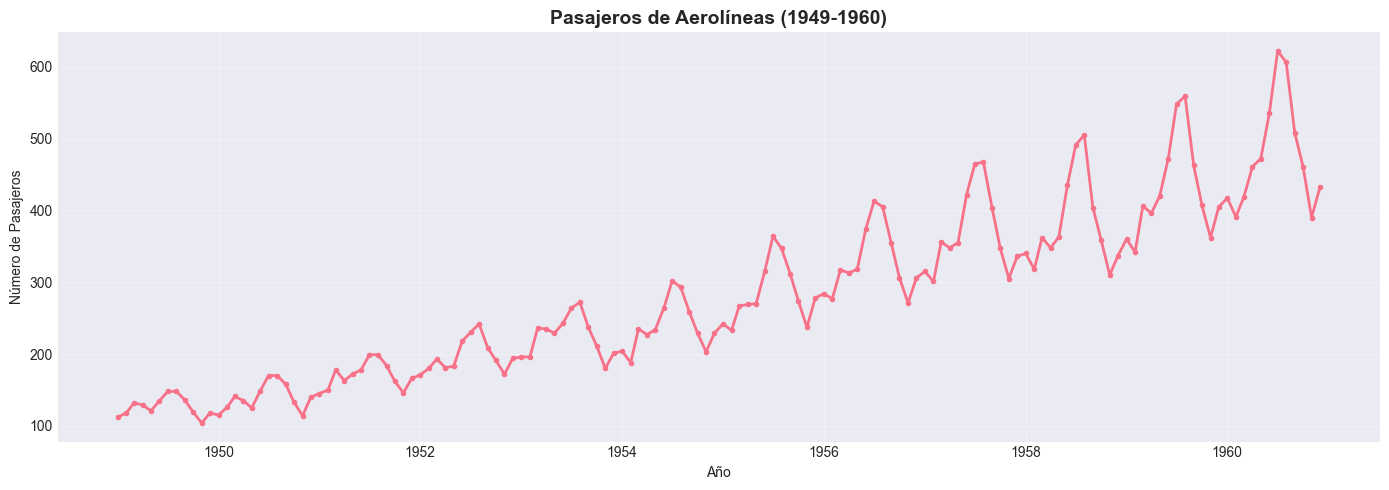

In [65]:
# Estadisticas descriptivas
print("Estadísticas Descriptivas:")
print(passengers.describe())

# Visualizacion
plt.figure(figsize=(14, 5))
plt.plot(passengers, marker='o', markersize=3, linewidth=2)
plt.title('Pasajeros de Aerolíneas (1949-1960)', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Número de Pasajeros')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Descomposición de la Serie

Vamos a descomponer la serie en sus componentes: tendencia, estacionalidad y residuos.

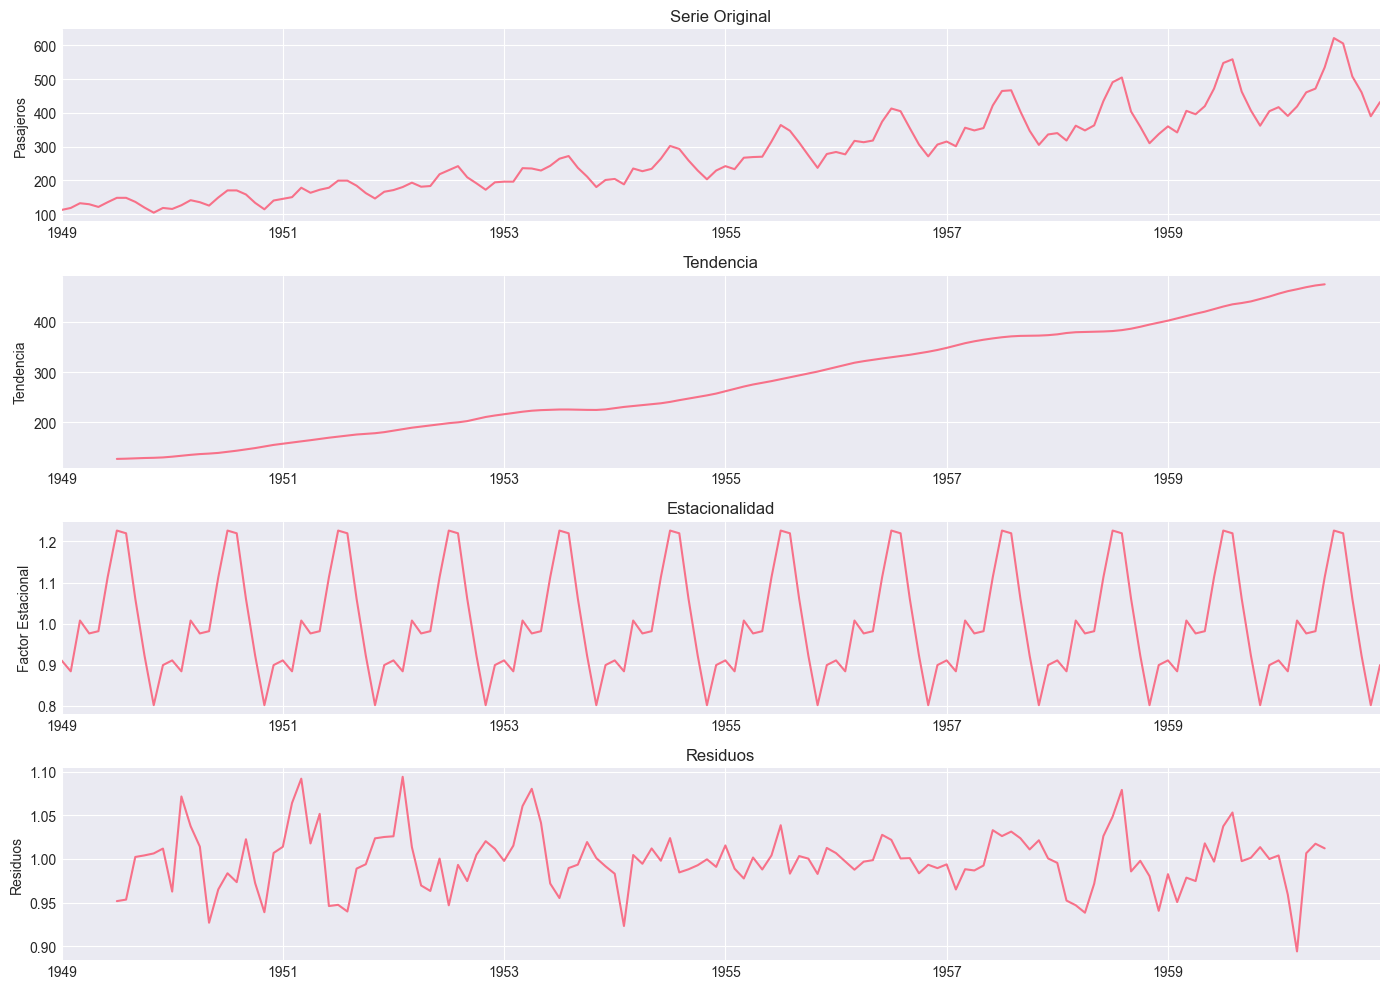


Interpretación:
- Tendencia: Crecimiento sostenido a lo largo de los 12 años
- Estacionalidad: Patrón anual claro (picos en verano, valles en invierno)
- Residuos: Componente aleatoria (ruido)


In [66]:
# Descomposicion multiplicativa (apropiada cuando la varianza crece)
decomposition = seasonal_decompose(passengers, model='multiplicative', period=12)

# Visualizar componentes
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=axes[0], title='Serie Original')
axes[0].set_ylabel('Pasajeros')

decomposition.trend.plot(ax=axes[1], title='Tendencia')
axes[1].set_ylabel('Tendencia')

decomposition.seasonal.plot(ax=axes[2], title='Estacionalidad')
axes[2].set_ylabel('Factor Estacional')

decomposition.resid.plot(ax=axes[3], title='Residuos')
axes[3].set_ylabel('Residuos')

plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("- Tendencia: Crecimiento sostenido a lo largo de los 12 años")
print("- Estacionalidad: Patrón anual claro (picos en verano, valles en invierno)")
print("- Residuos: Componente aleatoria (ruido)")

### 2.3 Análisis de Autocorrelación

Los gráficos ACF y PACF nos ayudan a entender la dependencia temporal.

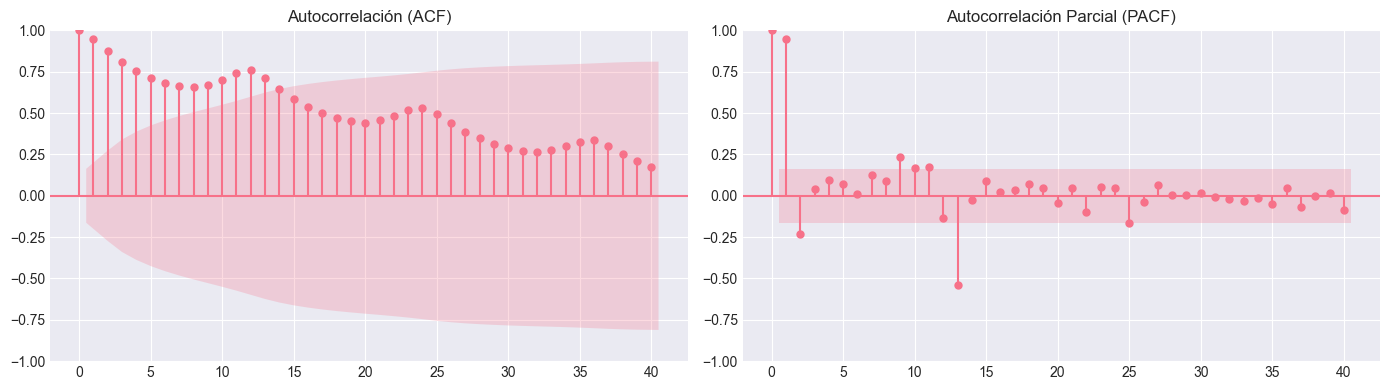


Observaciones:
- ACF decae lentamente: indica tendencia y no estacionaridad
- Picos cada 12 lags: confirma estacionalidad anual


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(passengers, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelación (ACF)')

plot_pacf(passengers, lags=40, ax=axes[1])
axes[1].set_title('Autocorrelación Parcial (PACF)')

plt.tight_layout()
plt.show()

print("\nObservaciones:")
print("- ACF decae lentamente: indica tendencia y no estacionaridad")
print("- Picos cada 12 lags: confirma estacionalidad anual")

### 2.4 División Train-Test

**Importante:** En series temporales respetamos el orden temporal.

Train: 1949-01-01 00:00:00 a 1958-12-01 00:00:00 (120 obs)
Test: 1959-01-01 00:00:00 a 1960-12-01 00:00:00 (24 obs)


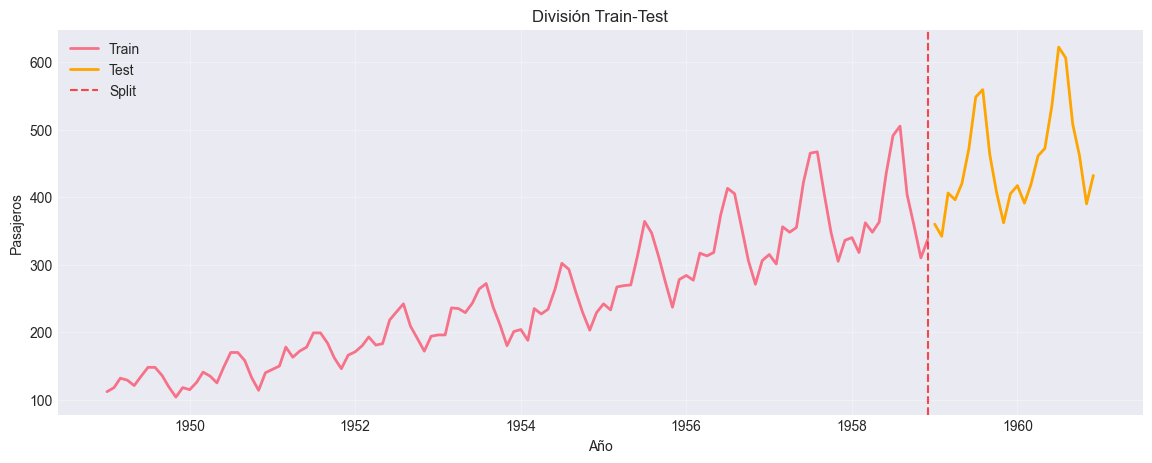

In [68]:
# Usar los primeros 120 meses (10 años) para entrenar
# Los ultimos 24 meses (2 años) para testear
train_passengers = passengers[:120]
test_passengers = passengers[120:]

print(f"Train: {train_passengers.index[0]} a {train_passengers.index[-1]} ({len(train_passengers)} obs)")
print(f"Test: {test_passengers.index[0]} a {test_passengers.index[-1]} ({len(test_passengers)} obs)")

# Visualizar
plt.figure(figsize=(14, 5))
plt.plot(train_passengers, label='Train', linewidth=2)
plt.plot(test_passengers, label='Test', linewidth=2, color='orange')
plt.axvline(x=train_passengers.index[-1], color='red', linestyle='--', alpha=0.7, label='Split')
plt.title('División Train-Test')
plt.xlabel('Año')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2.5 Media Móvil Simple

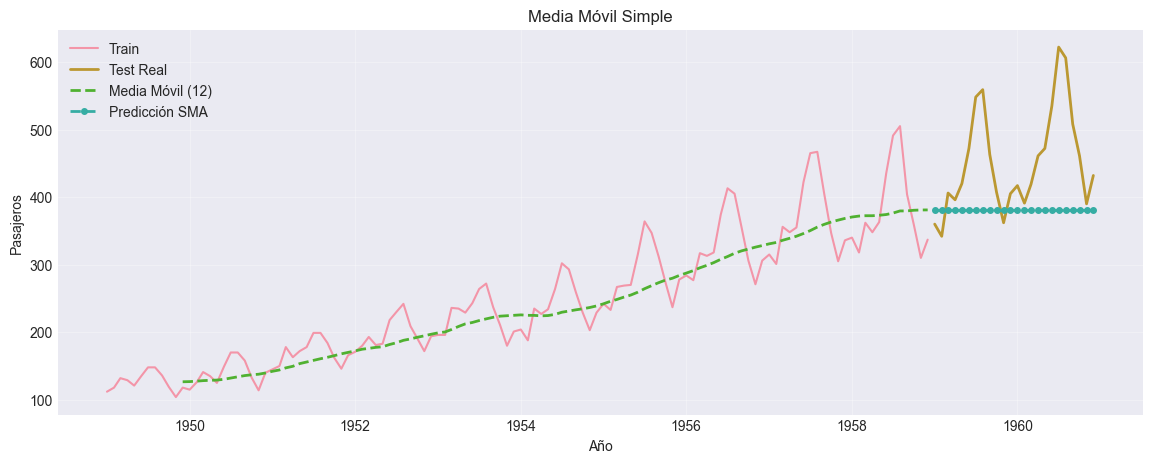

Limitación: La media móvil simple no captura tendencia ni estacionalidad en las predicciones.


In [69]:
# Media movil de 12 meses
ma_12 = train_passengers.rolling(window=12).mean()

# Prediccion: usar el ultimo valor de la media movil
last_ma = ma_12.iloc[-1]
sma_pred = pd.Series([last_ma] * len(test_passengers), index=test_passengers.index)

# Visualizar
plt.figure(figsize=(14, 5))
plt.plot(train_passengers, label='Train', alpha=0.7)
plt.plot(test_passengers, label='Test Real', linewidth=2)
plt.plot(ma_12, label='Media Móvil (12)', linestyle='--', linewidth=2)
plt.plot(sma_pred, label='Predicción SMA', linestyle='--', linewidth=2, marker='o', markersize=4)
plt.title('Media Móvil Simple')
plt.xlabel('Año')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Limitación: La media móvil simple no captura tendencia ni estacionalidad en las predicciones.")

### 2.6 Suavizamiento Exponencial Simple

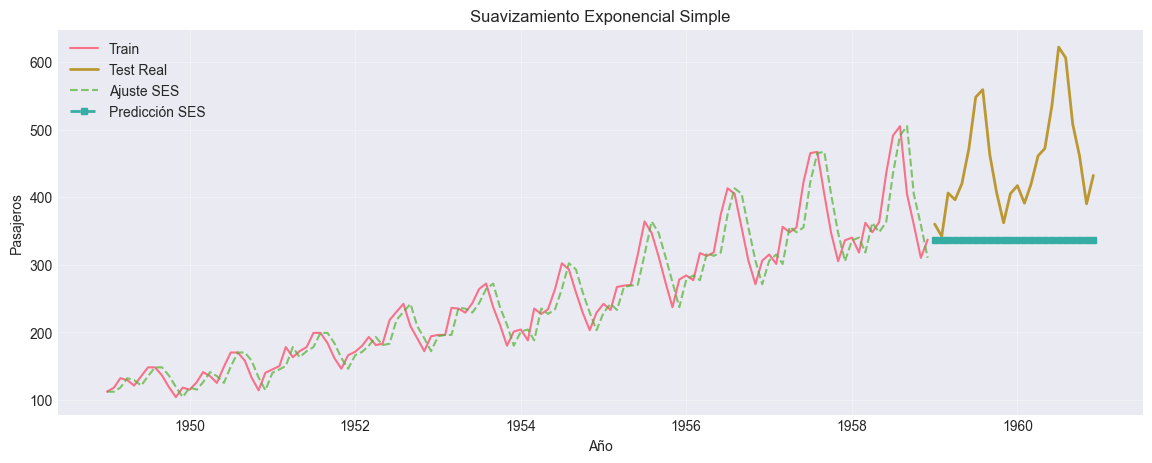

Alpha (nivel): 1.000

Limitación: No captura la tendencia creciente ni la estacionalidad.


In [70]:
# Entrenar modelo
model_ses = SimpleExpSmoothing(train_passengers)
fit_ses = model_ses.fit()

# Predecir
pred_ses = fit_ses.forecast(steps=len(test_passengers))

# Visualizar
plt.figure(figsize=(14, 5))
plt.plot(train_passengers, label='Train')
plt.plot(test_passengers, label='Test Real', linewidth=2)
plt.plot(fit_ses.fittedvalues, label='Ajuste SES', linestyle='--', alpha=0.7)
plt.plot(pred_ses, label='Predicción SES', linestyle='--', linewidth=2, marker='s', markersize=4)
plt.title('Suavizamiento Exponencial Simple')
plt.xlabel('Año')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Alpha (nivel): {fit_ses.params['smoothing_level']:.3f}")
print("\nLimitación: No captura la tendencia creciente ni la estacionalidad.")

### 2.7 Método de Holt (Doble Suavizamiento)

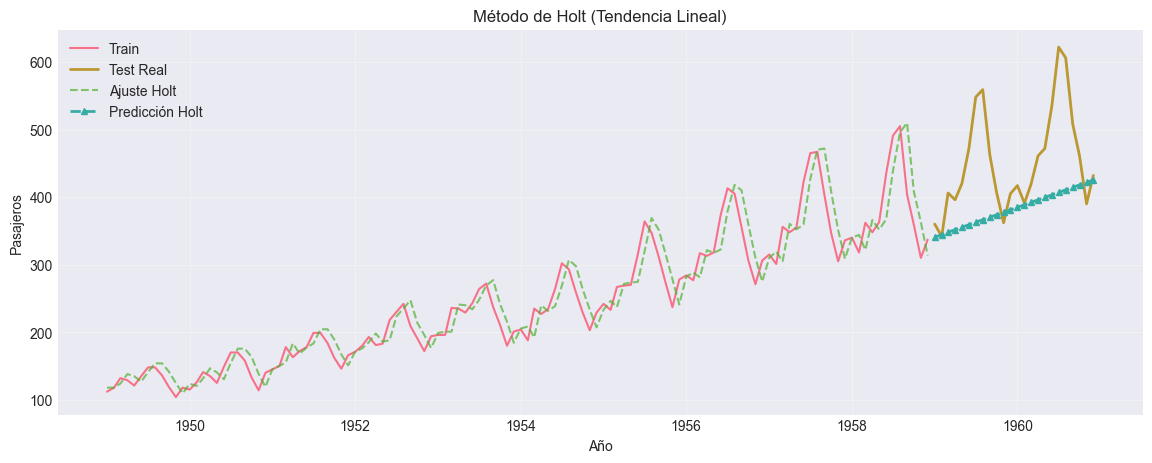

Alpha (nivel): 1.000
Beta (tendencia): 0.006

Mejora: Captura la tendencia creciente, pero no la estacionalidad.


In [71]:
# Entrenar modelo con tendencia
model_holt = Holt(train_passengers)
fit_holt = model_holt.fit()

# Predecir
pred_holt = fit_holt.forecast(steps=len(test_passengers))

# Visualizar
plt.figure(figsize=(14, 5))
plt.plot(train_passengers, label='Train')
plt.plot(test_passengers, label='Test Real', linewidth=2)
plt.plot(fit_holt.fittedvalues, label='Ajuste Holt', linestyle='--', alpha=0.7)
plt.plot(pred_holt, label='Predicción Holt', linestyle='--', linewidth=2, marker='^', markersize=4)
plt.title('Método de Holt (Tendencia Lineal)')
plt.xlabel('Año')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Alpha (nivel): {fit_holt.params['smoothing_level']:.3f}")
print(f"Beta (tendencia): {fit_holt.params['smoothing_trend']:.3f}")
print("\nMejora: Captura la tendencia creciente, pero no la estacionalidad.")

### 2.8 Holt-Winters (Triple Suavizamiento)

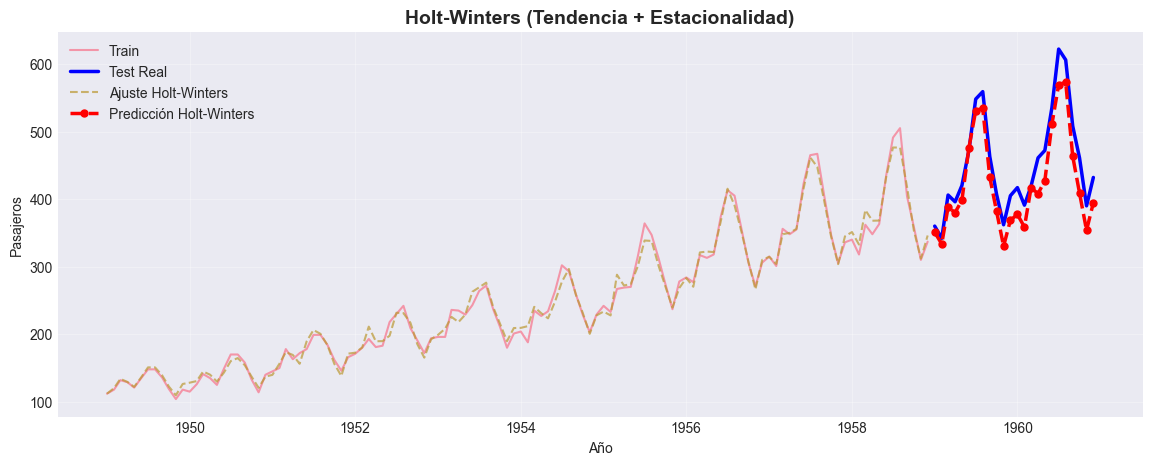

Alpha (nivel): 0.364
Beta (tendencia): 0.000
Gamma (estacionalidad): 0.636

¡Mucho mejor! Captura tanto la tendencia como la estacionalidad.


In [72]:
# Entrenar modelo con tendencia y estacionalidad multiplicativa
model_hw = ExponentialSmoothing(
    train_passengers,
    seasonal_periods=12,
    trend='add',
    seasonal='mul'
)
fit_hw = model_hw.fit()

# Predecir
pred_hw = fit_hw.forecast(steps=len(test_passengers))

# Visualizar
plt.figure(figsize=(14, 5))
plt.plot(train_passengers, label='Train', alpha=0.7)
plt.plot(test_passengers, label='Test Real', linewidth=2.5, color='blue')
plt.plot(fit_hw.fittedvalues, label='Ajuste Holt-Winters', linestyle='--', alpha=0.7)
plt.plot(pred_hw, label='Predicción Holt-Winters', linestyle='--', linewidth=2.5, 
         marker='o', markersize=5, color='red')
plt.title('Holt-Winters (Tendencia + Estacionalidad)', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Alpha (nivel): {fit_hw.params['smoothing_level']:.3f}")
print(f"Beta (tendencia): {fit_hw.params['smoothing_trend']:.3f}")
print(f"Gamma (estacionalidad): {fit_hw.params['smoothing_seasonal']:.3f}")
print("\n¡Mucho mejor! Captura tanto la tendencia como la estacionalidad.")

### 2.9 ARIMA

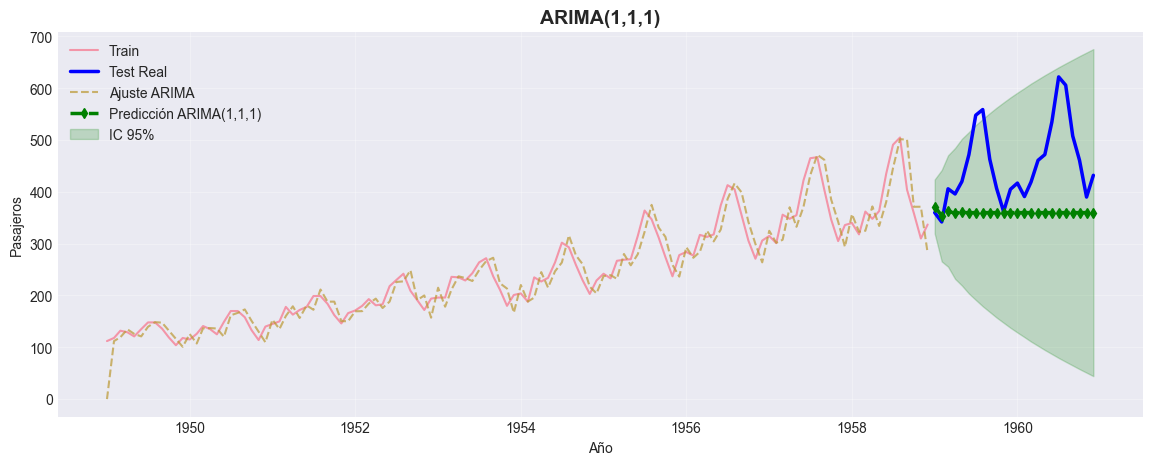

Coeficientes del modelo:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5120      0.148     -3.469      0.001      -0.801      -0.223
ma.L1          0.8746      0.097      8.977      0.000       0.684       1.066
sigma2       709.3300     83.383      8.507      0.000     545.903     872.757

Nota: ARIMA sin componente estacional no captura bien los patrones anuales.


In [73]:
# Entrenar ARIMA(1,1,1) - una configuracion simple
model_arima = ARIMA(train_passengers, order=(1, 1, 1))
fit_arima = model_arima.fit()

# Predecir
pred_arima = fit_arima.forecast(steps=len(test_passengers))

# Obtener intervalos de confianza
forecast_obj = fit_arima.get_forecast(steps=len(test_passengers))
pred_ci = forecast_obj.conf_int(alpha=0.05)

# Visualizar
plt.figure(figsize=(14, 5))
plt.plot(train_passengers, label='Train', alpha=0.7)
plt.plot(test_passengers, label='Test Real', linewidth=2.5, color='blue')
plt.plot(fit_arima.fittedvalues, label='Ajuste ARIMA', linestyle='--', alpha=0.7)
plt.plot(pred_arima, label='Predicción ARIMA(1,1,1)', linestyle='--', 
         linewidth=2.5, marker='d', markersize=5, color='green')

# Intervalo de confianza
plt.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], 
                 alpha=0.2, color='green', label='IC 95%')

plt.title('ARIMA(1,1,1)', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Coeficientes del modelo:")
print(fit_arima.summary().tables[1])
print("\nNota: ARIMA sin componente estacional no captura bien los patrones anuales.")

### 2.10 Comparación de Modelos


COMPARACIÓN DE MODELOS - Dataset Pasajeros
      Modelo        MAE       RMSE  MAPE (%)
Holt-Winters  28.977211  32.488626      6.41
        Holt  73.342377  97.712130     16.22
 Media Móvil  77.833333 103.214582     17.21
ARIMA(1,1,1)  93.904989 118.644527     20.76
         SES 115.250000 137.328985     25.48

Menor es mejor para todas las métricas

Ganador: Holt-Winters


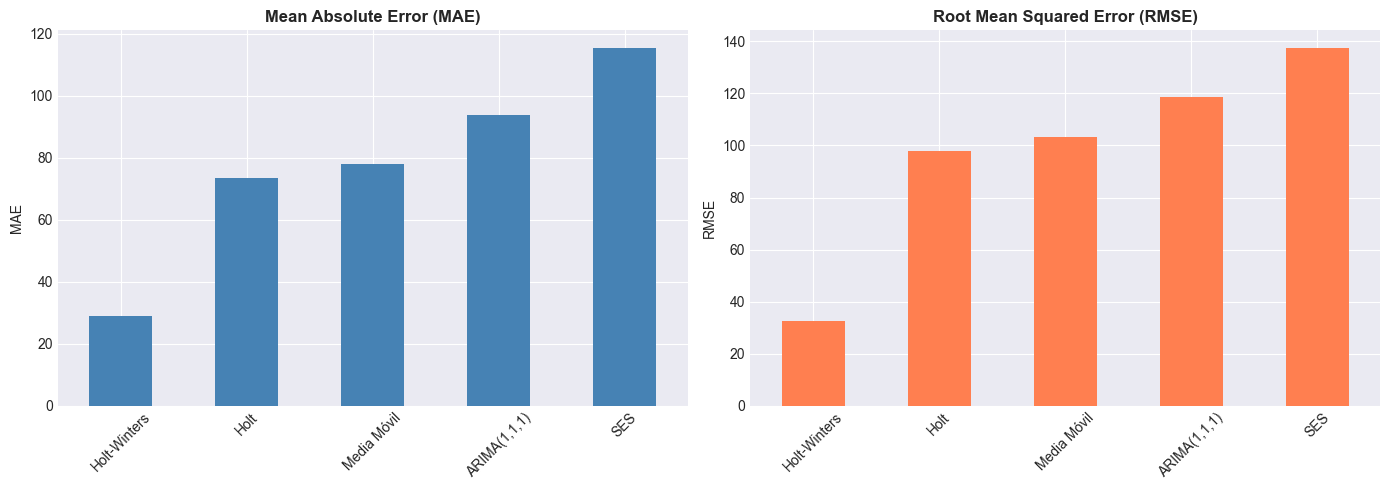

In [74]:
# Calcular metricas para cada modelo
resultados = {
    'Modelo': ['Media Móvil', 'SES', 'Holt', 'Holt-Winters', 'ARIMA(1,1,1)'],
    'MAE': [
        mean_absolute_error(test_passengers, sma_pred),
        mean_absolute_error(test_passengers, pred_ses),
        mean_absolute_error(test_passengers, pred_holt),
        mean_absolute_error(test_passengers, pred_hw),
        mean_absolute_error(test_passengers, pred_arima)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(test_passengers, sma_pred)),
        np.sqrt(mean_squared_error(test_passengers, pred_ses)),
        np.sqrt(mean_squared_error(test_passengers, pred_holt)),
        np.sqrt(mean_squared_error(test_passengers, pred_hw)),
        np.sqrt(mean_squared_error(test_passengers, pred_arima))
    ]
}

df_resultados = pd.DataFrame(resultados)
df_resultados['MAPE (%)'] = (
    df_resultados['MAE'] / test_passengers.mean() * 100
).round(2)

df_resultados = df_resultados.sort_values('MAE')

print("\n" + "="*60)
print("COMPARACIÓN DE MODELOS - Dataset Pasajeros")
print("="*60)
print(df_resultados.to_string(index=False))
print("\nMenor es mejor para todas las métricas")
print(f"\nGanador: {df_resultados.iloc[0]['Modelo']}")

# Grafico de barras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_resultados.plot(x='Modelo', y='MAE', kind='bar', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Mean Absolute Error (MAE)', fontweight='bold')
axes[0].set_ylabel('MAE')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

df_resultados.plot(x='Modelo', y='RMSE', kind='bar', ax=axes[1], legend=False, color='coral')
axes[1].set_title('Root Mean Squared Error (RMSE)', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Dataset 2: Precio de Acciones (Simulado)

Ahora vamos a trabajar con datos financieros simulados. A diferencia de la demanda de pasajeros:
- Puede tener tendencia menos clara
- Mayor volatilidad
- Sin estacionalidad fuerte

In [75]:
# Generar serie temporal de precio de acciones simulada
np.random.seed(42)

# Parametros
n_dias = 500
precio_inicial = 100
tendencia_diaria = 0.05
volatilidad = 2.0

# Generar precios con tendencia y ruido
fechas_stock = pd.date_range('2022-01-01', periods=n_dias, freq='D')
tendencia = np.linspace(0, tendencia_diaria * n_dias, n_dias)
ruido = np.random.normal(0, volatilidad, n_dias).cumsum()
precios = precio_inicial + tendencia + ruido

stock = pd.Series(precios, index=fechas_stock, name='Precio')

print(f"Periodo: {stock.index[0].date()} a {stock.index[-1].date()}")
print(f"Total de días: {len(stock)}")
print(f"\nEstadísticas:")
print(stock.describe())

Periodo: 2022-01-01 a 2023-05-15
Total de días: 500

Estadísticas:
count    500.000000
mean     109.755405
std       20.227298
min       78.156530
25%       89.685320
50%      108.975332
75%      128.816635
max      152.714177
Name: Precio, dtype: float64


### 3.1 Exploración - Datos Financieros

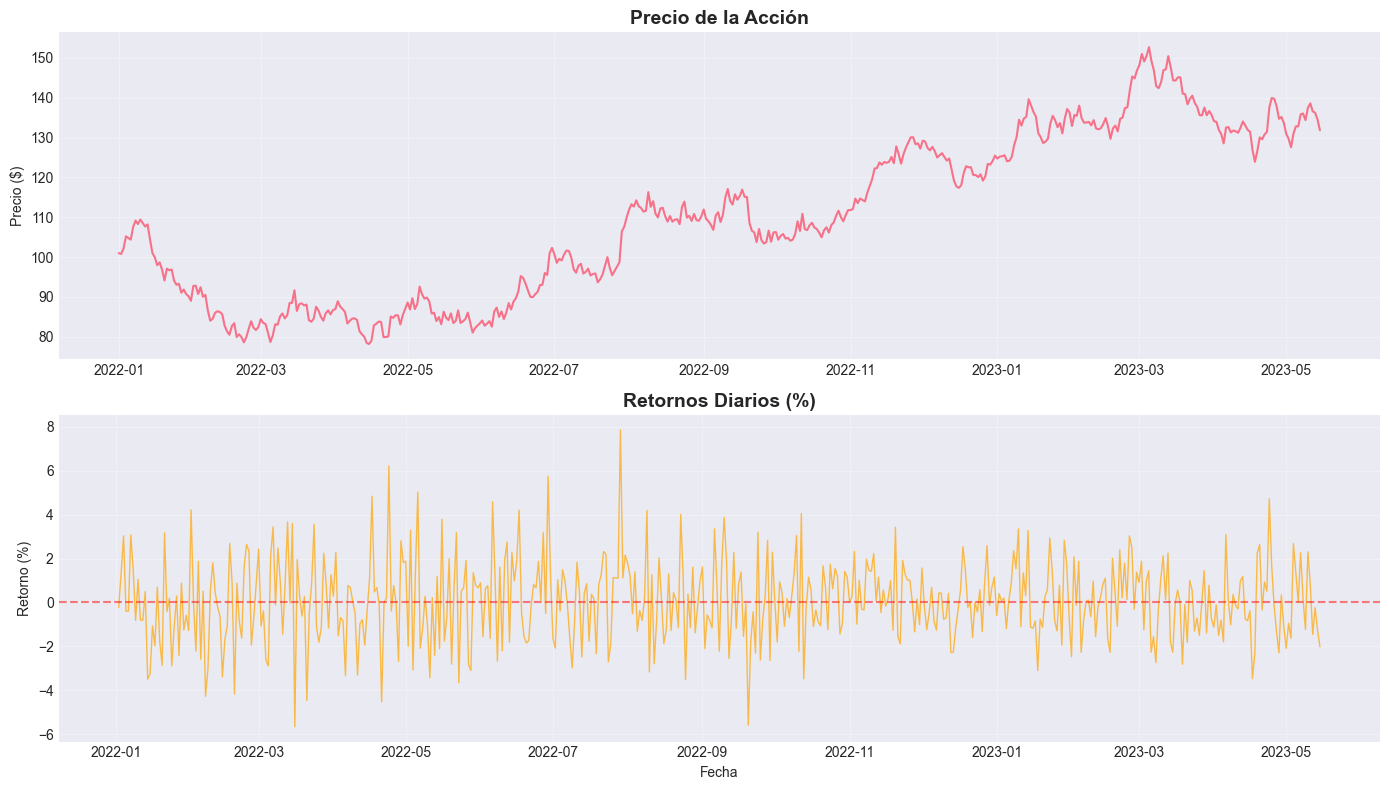

Volatilidad (std de retornos): 1.86%


In [76]:
# Visualizacion
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Precio
axes[0].plot(stock, linewidth=1.5)
axes[0].set_title('Precio de la Acción', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Precio ($)')
axes[0].grid(True, alpha=0.3)

# Retornos diarios
retornos = stock.pct_change().dropna() * 100
axes[1].plot(retornos, linewidth=1, alpha=0.7, color='orange')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Retornos Diarios (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Retorno (%)')
axes[1].set_xlabel('Fecha')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Volatilidad (std de retornos): {retornos.std():.2f}%")

### 3.2 Descomposición - Datos Financieros

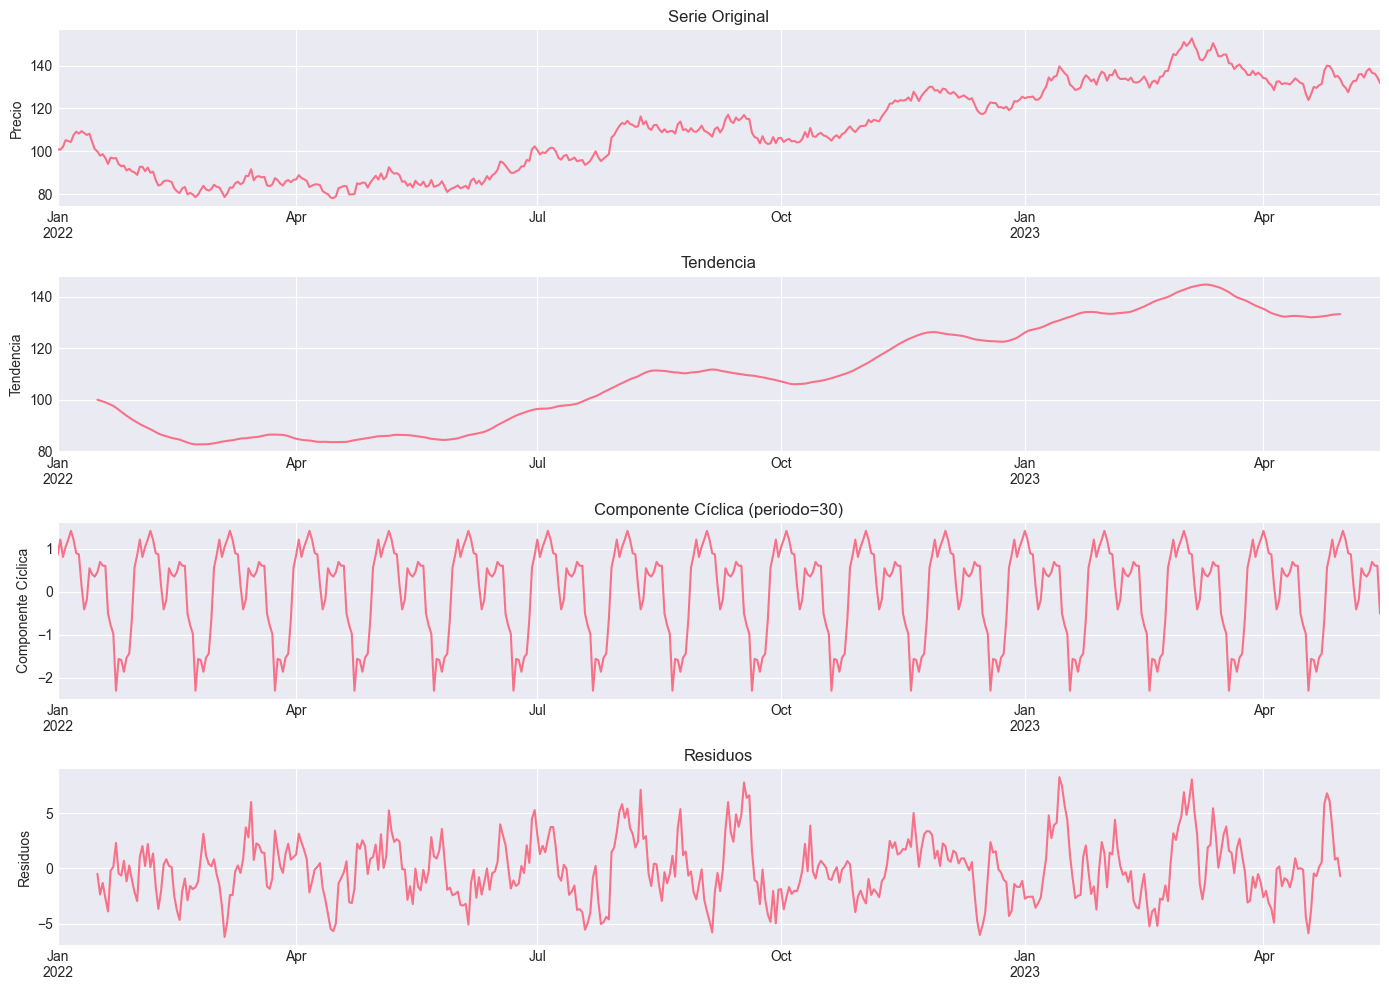

Observación: Los datos financieros tienen más ruido y menos estacionalidad.


In [77]:
# Usar descomposicion aditiva (no hay estacionalidad clara)
# Periodo arbitrario de 30 dias para suavizado
decomposition_stock = seasonal_decompose(stock, model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition_stock.observed.plot(ax=axes[0], title='Serie Original')
axes[0].set_ylabel('Precio')

decomposition_stock.trend.plot(ax=axes[1], title='Tendencia')
axes[1].set_ylabel('Tendencia')

decomposition_stock.seasonal.plot(ax=axes[2], title='Componente Cíclica (periodo=30)')
axes[2].set_ylabel('Componente Cíclica')

decomposition_stock.resid.plot(ax=axes[3], title='Residuos')
axes[3].set_ylabel('Residuos')

plt.tight_layout()
plt.show()

print("Observación: Los datos financieros tienen más ruido y menos estacionalidad.")

### 3.3 División Train-Test - Datos Financieros

Train: 2022-01-01 a 2023-02-04 (400 días)
Test: 2023-02-05 a 2023-05-15 (100 días)


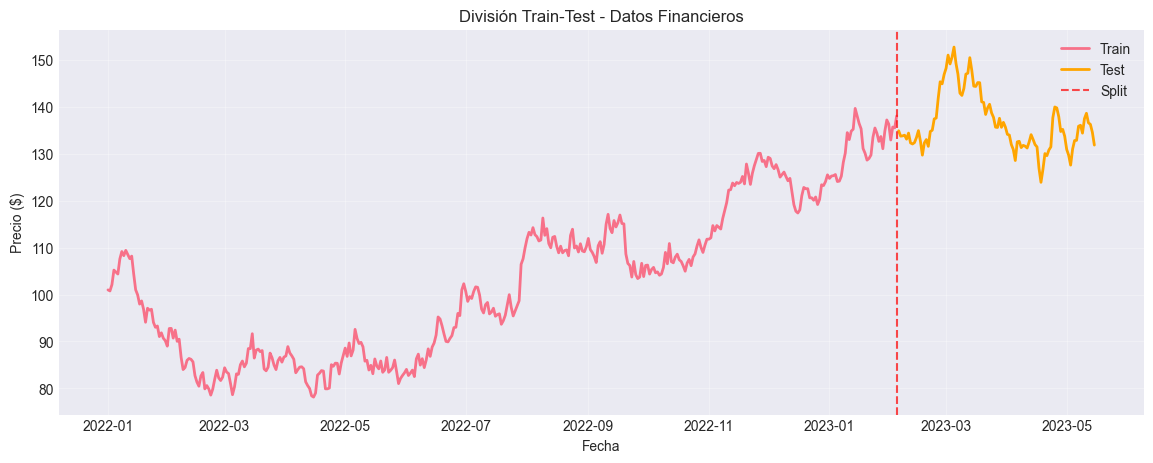

In [78]:
# Usar primeros 400 dias para train, ultimos 100 para test
train_stock = stock[:400]
test_stock = stock[400:]

print(f"Train: {train_stock.index[0].date()} a {train_stock.index[-1].date()} ({len(train_stock)} días)")
print(f"Test: {test_stock.index[0].date()} a {test_stock.index[-1].date()} ({len(test_stock)} días)")

plt.figure(figsize=(14, 5))
plt.plot(train_stock, label='Train', linewidth=2)
plt.plot(test_stock, label='Test', linewidth=2, color='orange')
plt.axvline(x=train_stock.index[-1], color='red', linestyle='--', alpha=0.7, label='Split')
plt.title('División Train-Test - Datos Financieros')
plt.xlabel('Fecha')
plt.ylabel('Precio ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.4 Modelos - Datos Financieros

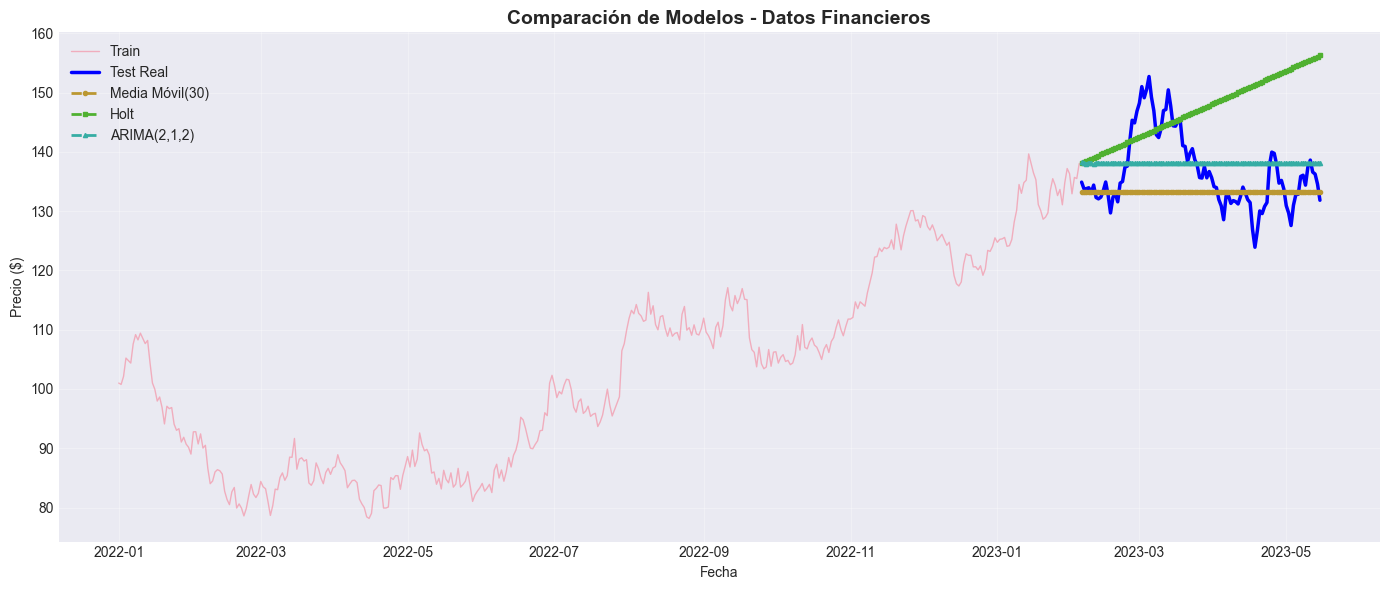

In [79]:
# Media Movil
ma_30_stock = train_stock.rolling(window=30).mean()
sma_pred_stock = pd.Series([ma_30_stock.iloc[-1]] * len(test_stock), index=test_stock.index)

# Holt (con tendencia, sin estacionalidad)
model_holt_stock = Holt(train_stock)
fit_holt_stock = model_holt_stock.fit()
pred_holt_stock = fit_holt_stock.forecast(steps=len(test_stock))

# ARIMA(2,1,2)
model_arima_stock = ARIMA(train_stock, order=(2, 1, 2))
fit_arima_stock = model_arima_stock.fit()
pred_arima_stock = fit_arima_stock.forecast(steps=len(test_stock))

# Visualizar todos los modelos
plt.figure(figsize=(14, 6))
plt.plot(train_stock, label='Train', alpha=0.5, linewidth=1)
plt.plot(test_stock, label='Test Real', linewidth=2.5, color='blue')
plt.plot(sma_pred_stock, label='Media Móvil(30)', linestyle='--', linewidth=2, marker='o', markersize=3)
plt.plot(pred_holt_stock, label='Holt', linestyle='--', linewidth=2, marker='s', markersize=3)
plt.plot(pred_arima_stock, label='ARIMA(2,1,2)', linestyle='--', linewidth=2, marker='^', markersize=3)

plt.title('Comparación de Modelos - Datos Financieros', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Precio ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6 Comparación de Modelos - Datos Financieros


COMPARACIÓN DE MODELOS - Dataset Financiero
         Modelo       MAE      RMSE  MAPE (%)
Media Móvil(30)  5.111104  7.195677      3.74
   ARIMA(2,1,2)  5.455036  6.395111      3.99
           Holt 11.874752 14.069766      8.69

Menor es mejor para todas las métricas

Ganador: Media Móvil(30)


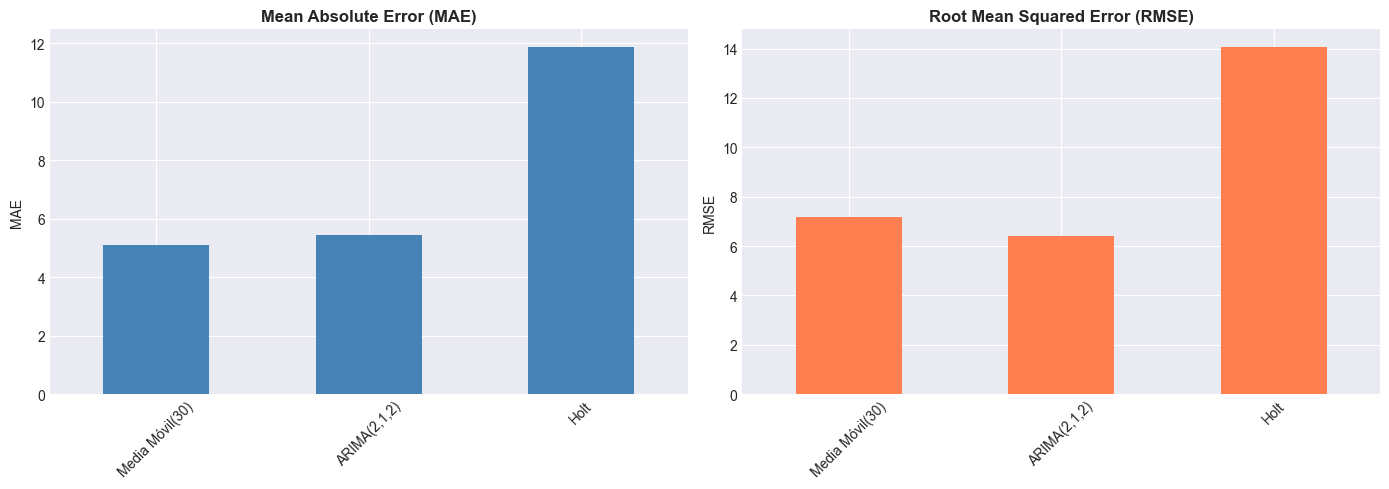

In [80]:
# Calcular metricas
resultados_stock = {
    'Modelo': ['Media Móvil(30)', 'Holt', 'ARIMA(2,1,2)'],
    'MAE': [
        mean_absolute_error(test_stock, sma_pred_stock),
        mean_absolute_error(test_stock, pred_holt_stock),
        mean_absolute_error(test_stock, pred_arima_stock)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(test_stock, sma_pred_stock)),
        np.sqrt(mean_squared_error(test_stock, pred_holt_stock)),
        np.sqrt(mean_squared_error(test_stock, pred_arima_stock))
    ]
}

df_resultados_stock = pd.DataFrame(resultados_stock)
df_resultados_stock['MAPE (%)'] = (
    df_resultados_stock['MAE'] / test_stock.mean() * 100
).round(2)

df_resultados_stock = df_resultados_stock.sort_values('MAE')

print("\n" + "="*60)
print("COMPARACIÓN DE MODELOS - Dataset Financiero")
print("="*60)
print(df_resultados_stock.to_string(index=False))
print("\nMenor es mejor para todas las métricas")
print(f"\nGanador: {df_resultados_stock.iloc[0]['Modelo']}")

# Grafico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_resultados_stock.plot(x='Modelo', y='MAE', kind='bar', ax=axes[0], 
                          legend=False, color='steelblue')
axes[0].set_title('Mean Absolute Error (MAE)', fontweight='bold')
axes[0].set_ylabel('MAE')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

df_resultados_stock.plot(x='Modelo', y='RMSE', kind='bar', ax=axes[1], 
                          legend=False, color='coral')
axes[1].set_title('Root Mean Squared Error (RMSE)', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Modelos Avanzados con Dataset Pasajeros

Ahora probemos modelos más sofisticados con el dataset de pasajeros.

### 4.1 Auto ARIMA

Auto ARIMA prueba automáticamente diferentes combinaciones de parámetros.

In [81]:
# Primero instala pmdarima si no lo tienes: pip install pmdarima
try:
    from pmdarima import auto_arima
    
    # Buscar el mejor modelo automaticamente
    modelo_auto = auto_arima(
        train_passengers,
        start_p=0, max_p=3,
        start_q=0, max_q=3,
        d=None,  # Se determina automaticamente
        seasonal=False,
        trace=True,  # Muestra el proceso de busqueda
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )
    
    print(modelo_auto.summary())
    
    # Predicciones
    predicciones_auto = modelo_auto.predict(n_periods=len(test_passengers))
    predicciones_auto = pd.Series(predicciones_auto, index=test_passengers.index)
    
    # Calcular metricas
    mae_auto = mean_absolute_error(test_passengers, predicciones_auto)
    rmse_auto = np.sqrt(mean_squared_error(test_passengers, predicciones_auto))
    
    print(f"\nAuto ARIMA - MAE: {mae_auto:.2f}, RMSE: {rmse_auto:.2f}")
    
    # Visualizar
    plt.figure(figsize=(14, 5))
    plt.plot(train_passengers, label='Train', alpha=0.7)
    plt.plot(test_passengers, label='Test Real', linewidth=2.5)
    plt.plot(predicciones_auto, label='Auto ARIMA', linestyle='--', linewidth=2.5, marker='o')
    plt.title('Auto ARIMA - Mejor Modelo Automático')
    plt.xlabel('Año')
    plt.ylabel('Pasajeros')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
except ImportError:
    print("pmdarima no está instalado. Ejecuta: pip install pmdarima (verificando antes que estes con Python entre 3.8 y 3.11)")

pmdarima no está instalado. Ejecuta: pip install pmdarima (verificando antes que estes con Python entre 3.8 y 3.11)


### 4.2 SARIMA - ARIMA con Estacionalidad

SARIMA captura tanto tendencia como estacionalidad. Esto no está en la clase, es extra para el que le interese.

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -398.830
Date:                            Sun, 09 Nov 2025   AIC                            807.660
Time:                                    23:53:42   BIC                            821.024
Sample:                                01-01-1949   HQIC                           813.078
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4901      0.351     -1.397      0.162      -1.178       0.197
ma.L1          0.2579      0.373   

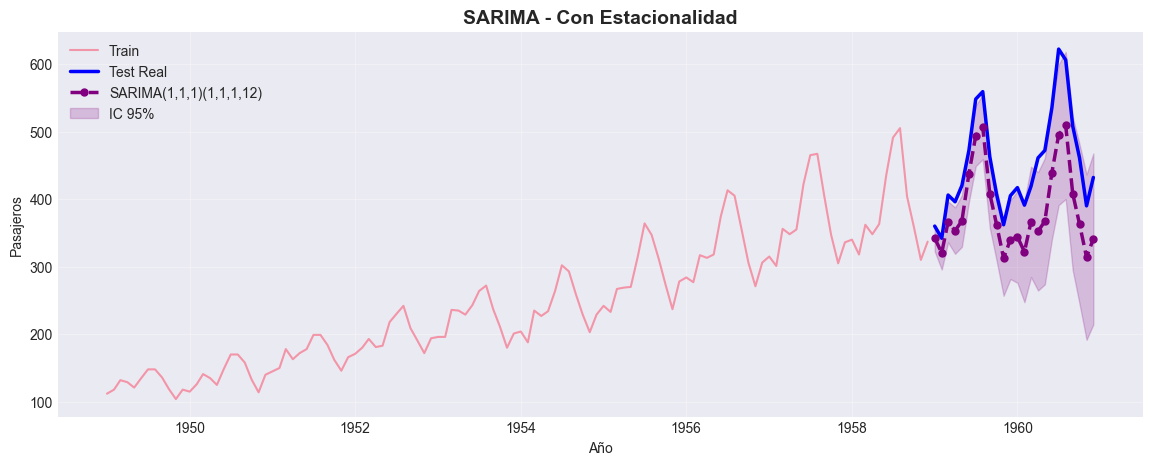

In [82]:
# SARIMA con estacionalidad anual (s=12)
# order=(1, 1, 1): componentes no estacionales (p, d, q)
# seasonal_order=(1, 1, 1, 12): componentes estacionales (P, D, Q, s)
modelo_sarima = SARIMAX(
    train_passengers,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)
fit_sarima = modelo_sarima.fit()

print(fit_sarima.summary())

# Predicciones
pred_sarima = fit_sarima.forecast(steps=len(test_passengers))

# Obtener intervalos de confianza
forecast_sarima = fit_sarima.get_forecast(steps=len(test_passengers))
pred_ci_sarima = forecast_sarima.conf_int(alpha=0.05)

# Calcular metricas
mae_sarima = mean_absolute_error(test_passengers, pred_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test_passengers, pred_sarima))

print(f"\nSARIMA - MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f}")

# Visualizar
plt.figure(figsize=(14, 5))
plt.plot(train_passengers, label='Train', alpha=0.7)
plt.plot(test_passengers, label='Test Real', linewidth=2.5, color='blue')
plt.plot(pred_sarima, label='SARIMA(1,1,1)(1,1,1,12)', linestyle='--', 
         linewidth=2.5, marker='o', markersize=5, color='purple')
plt.fill_between(pred_ci_sarima.index, 
                 pred_ci_sarima.iloc[:, 0], 
                 pred_ci_sarima.iloc[:, 1], 
                 alpha=0.2, color='purple', label='IC 95%')
plt.title('SARIMA - Con Estacionalidad', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Cross-Validation para Series Temporales

En series temporales NO podemos mezclar los datos. Usamos validación temporal.

### 5.1 TimeSeriesSplit - Rolling Window

El tamaño del train se mantiene constante y "desliza" hacia adelante.

Fold 1: Train size=24, Test size=24
  MAE: 32.45, RMSE: 39.23

Fold 2: Train size=48, Test size=24
  MAE: 35.71, RMSE: 45.15

Fold 3: Train size=72, Test size=24
  MAE: 74.54, RMSE: 88.96

Fold 4: Train size=96, Test size=24
  MAE: 60.12, RMSE: 81.72

Fold 5: Train size=120, Test size=24
  MAE: 93.90, RMSE: 118.64

MAE promedio: 59.35 (+/- 23.27)
RMSE promedio: 74.74 (+/- 29.38)


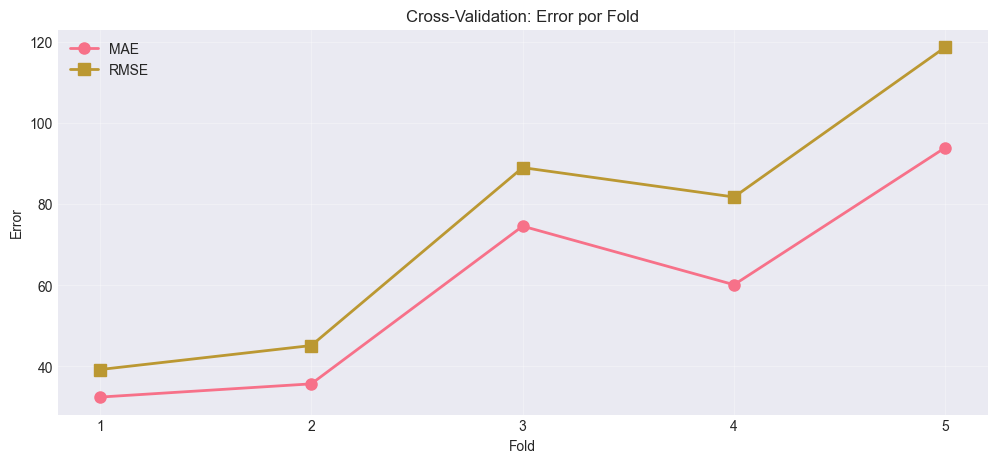

In [83]:
# Configurar cross-validation temporal
tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []

for fold, (train_index, test_index) in enumerate(tscv.split(passengers)):
    train = passengers.iloc[train_index]
    test = passengers.iloc[test_index]
    
    print(f"Fold {fold+1}: Train size={len(train)}, Test size={len(test)}")

    # Entrenar modelo (ejemplo con ARIMA)
    modelo = ARIMA(train, order=(1,1,1))
    fit = modelo.fit()

    # Predecir
    predicciones = fit.forecast(steps=len(test))

    # Calcular metricas
    mae = mean_absolute_error(test, predicciones)
    rmse = np.sqrt(mean_squared_error(test, predicciones))

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f"  MAE: {mae:.2f}, RMSE: {rmse:.2f}\n")

print("="*60)
print(f"MAE promedio: {np.mean(mae_scores):.2f} (+/- {np.std(mae_scores):.2f})")
print(f"RMSE promedio: {np.mean(rmse_scores):.2f} (+/- {np.std(rmse_scores):.2f})")

# Visualizar
plt.figure(figsize=(12, 5))
plt.plot(range(1, 6), mae_scores, 'o-', linewidth=2, markersize=8, label='MAE')
plt.plot(range(1, 6), rmse_scores, 's-', linewidth=2, markersize=8, label='RMSE')
plt.xlabel('Fold')
plt.ylabel('Error')
plt.title('Cross-Validation: Error por Fold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 6))
plt.show()

### 5.2 Expanding Window

El train crece en cada iteración (siempre incluye todos los datos históricos).

Fold 1: Train size=72, Test size=14
  MAE: 51.89, RMSE: 63.99

Fold 2: Train size=86, Test size=14
  MAE: 57.00, RMSE: 68.40

Fold 3: Train size=100, Test size=14
  MAE: 45.30, RMSE: 62.62

Fold 4: Train size=114, Test size=14
  MAE: 72.14, RMSE: 80.10

Fold 5: Train size=128, Test size=14
  MAE: 100.70, RMSE: 111.21

MAE promedio: 65.41 (+/- 19.74)
RMSE promedio: 77.26 (+/- 18.05)


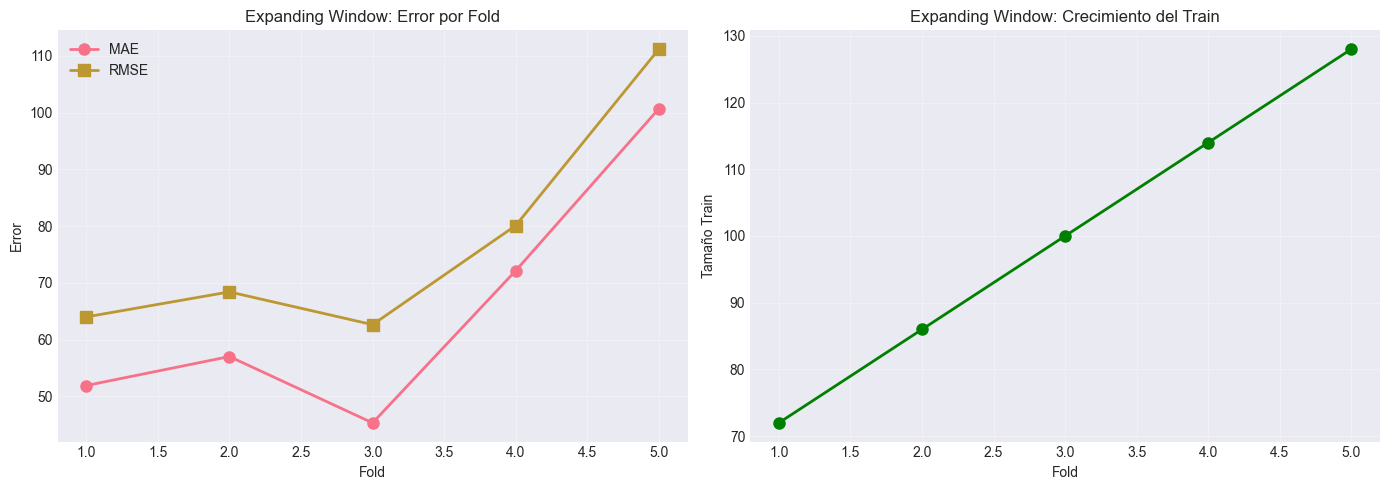

In [84]:
# Expanding window: el train crece en cada iteracion
train_size_initial = int(len(passengers) * 0.5)  # Empezar con 50% de los datos
n_folds = 5
test_size = (len(passengers) - train_size_initial) // n_folds

mae_scores_exp = []
rmse_scores_exp = []
train_sizes = []

for i in range(n_folds):
    # El train crece en cada iteracion
    train_end = train_size_initial + i * test_size
    test_start = train_end
    test_end = min(train_end + test_size, len(passengers))
    
    train = passengers[:train_end]
    test = passengers[test_start:test_end]
    
    if len(test) == 0:
        break
    
    train_sizes.append(len(train))
    print(f"Fold {i+1}: Train size={len(train)}, Test size={len(test)}")
    
    # Entrenar y evaluar modelo
    modelo = ARIMA(train, order=(1,1,1))
    fit = modelo.fit()
    predicciones = fit.forecast(steps=len(test))
    
    mae = mean_absolute_error(test, predicciones)
    rmse = np.sqrt(mean_squared_error(test, predicciones))
    
    mae_scores_exp.append(mae)
    rmse_scores_exp.append(rmse)
    print(f"  MAE: {mae:.2f}, RMSE: {rmse:.2f}\n")

print("="*60)
print(f"MAE promedio: {np.mean(mae_scores_exp):.2f} (+/- {np.std(mae_scores_exp):.2f})")
print(f"RMSE promedio: {np.mean(rmse_scores_exp):.2f} (+/- {np.std(rmse_scores_exp):.2f})")

# Visualizar crecimiento del train
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(mae_scores_exp)+1), mae_scores_exp, 'o-', linewidth=2, markersize=8, label='MAE')
axes[0].plot(range(1, len(rmse_scores_exp)+1), rmse_scores_exp, 's-', linewidth=2, markersize=8, label='RMSE')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Error')
axes[0].set_title('Expanding Window: Error por Fold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(train_sizes)+1), train_sizes, 'o-', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Tamaño Train')
axes[1].set_title('Expanding Window: Crecimiento del Train')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()